# CricMetrics Pro: Multi-Dimensional Cricket Player Performance Analysis
### Case Study: Player Performance Analysis | End-to-End Machine Learning System
**Student-Formulated Project Title:** CricMetrics Pro: AI-Powered Multi-Task Cricket Performance Analytics, Talent Tier Classification & Fair Market Valuation  
**Focus:** Professional T20 Cricket Analytics, Athletic & Tactical Telemetry, and Franchise Decision Support  
**Domain:** Indian Premier League (IPL) & Global T20 Franchise Intelligence (17 Seasons: 2008–2024)

---
## 1. Executive Summary & Problem Formulation
In high-stakes professional franchise sports (e.g. IPL mega-auctions with ₹100+ Crore purse limits), recruitment scouting, salary valuation, and match-up deployments require quantitative, evidence-based evaluation. Traditional scouting often suffers from cognitive heuristics, superstar bias, and over-indexing on nominal aggregate runs or wickets.

**Assigned Problem Statement:**
> *A sports organization wants to investigate measurable factors associated with player performance (With Proper Justification).*

### Formal Machine Learning Problem Formulation:
1. **Supervised Regression Task:** Predict a continuous **Overall Performance Rating (50.0 to 95.0)** and estimate fair market auction purse (₹ Crores) based on empirical efficiency and situational impact.
2. **Supervised Classification Task:** Categorize players into 3 discrete organizational tiers:
   - **Tier 2 (Elite / Marquee):** Game-changing franchise anchors, death finishers, and strike bowlers.
   - **Tier 1 (Core / Star):** Reliable starting XI role specialists.
   - **Tier 0 (Developing / Squad):** Emerging uncapped domestic talent and depth backups.
3. **Unsupervised Clustering Task:** Partition cricketers into natural tactical role archetypes ($k=5$) using K-Means without subjective human labeling.
4. **Dimensionality Reduction Task:** Project 26 multi-dimensional factors into an interpretable 2D latent space via Principal Component Analysis (PCA).

---
## 2. Environment Setup & Dependency Loading
Loading numerical, tabular, statistical, modeling, and visualization libraries.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

print(f'Python environment verified. NumPy: {np.__version__}, Pandas: {pd.__version__}')

Python environment verified. NumPy: 2.0.2, Pandas: 2.3.3


---
## 3. Dataset Ingestion & Schema Verification
The dataset is derived from 260,920 legal ball-by-ball delivery event logs across 1,095 IPL matches spanning 17 complete seasons (2008–2024).

In [2]:
# Check both relative and current working directory paths
DATA_PATH = '../data/processed/cricket_players_clean.csv' if os.path.exists('../data/processed/cricket_players_clean.csv') else 'data/processed/cricket_players_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset Loaded Successfully: {df.shape[0]} qualified players, {df.shape[1]} features.')
print(f'Columns: {list(df.columns[:10])} ... and {len(df.columns)-10} more.')
display(df[['player_name', 'primary_role', 'matches_played', 'total_runs', 'batting_strike_rate', 'wickets_taken', 'economy_rate', 'overall_performance_rating', 'performance_tier']].head())

Dataset Loaded Successfully: 619 qualified players, 31 features.
Columns: ['player_name', 'matches_played', 'primary_role', 'total_runs', 'balls_faced', 'batting_average', 'batting_strike_rate', 'fours', 'sixes', 'boundary_run_pct'] ... and 21 more.


,player_name,primary_role,matches_played,total_runs,batting_strike_rate,wickets_taken,economy_rate,overall_performance_rating,performance_tier
0,A Ashish Reddy,Specialist Bowler,23,280,142.86,18,8.58,79.9,Core / Star
1,A Badoni,Specialist Batter,35,634,125.54,2,9.50,74.8,Core / Star
2,A Chandila,Bowling Specialist,12,4,57.14,11,6.21,64.1,Developing / Squad
3,A Chopra,Squad Batter,6,53,70.67,0,10.50,64.0,Developing / Squad
4,A Choudhary,Bowling Specialist,5,25,125.00,5,7.61,75.5,Core / Star


---
## 4. Data Cleaning, Missing Value Imputation & Feature Scaling
- Handled division-by-zero for non-batters and non-bowlers with domain-specific replacement logic.
- Applied One-Hot Encoding (`pd.get_dummies`) with `drop_first=True` to categorical role identifiers.
- Applied `StandardScaler` to ensure zero mean ($\mu = 0$) and unit variance ($\sigma^2 = 1$).
- Stratified 80/20 train/test split preserving performance tier class distribution.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_features = [
    'matches_played', 'total_runs', 'balls_faced', 'batting_average',
    'batting_strike_rate', 'fours', 'sixes', 'boundary_run_pct',
    'dot_ball_faced_pct', 'highest_score', 'thirties', 'fifties',
    'death_overs_strike_rate', 'overs_bowled', 'wickets_taken',
    'economy_rate', 'bowling_strike_rate', 'bowling_average',
    'dot_ball_bowled_pct', 'three_plus_wickets', 'death_overs_economy',
    'player_of_match_awards', 'batting_impact_index', 'bowling_impact_index',
    'clutch_match_winner_index'
]
cat_features = ['primary_role']

# One-hot encode roles
df_encoded = pd.get_dummies(df[num_features + cat_features], columns=cat_features, drop_first=True, dtype=float)

y_reg = df['overall_performance_rating']
y_clf = df['performance_tier_code']

# 80/20 Stratified Partitioning
X_train_raw, X_test_raw, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    df_encoded, y_reg, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=df_encoded.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=df_encoded.columns)

print(f'Train set: {X_train.shape[0]} players | Test set: {X_test.shape[0]} players | Features: {X_train.shape[1]}')

Train set: 495 players | Test set: 124 players | Features: 29


---
## 5. Exploratory Data Analysis (EDA) & Factor Insights
Visualizing correlation structures and multi-dimensional attribute fingerprints across playing roles.

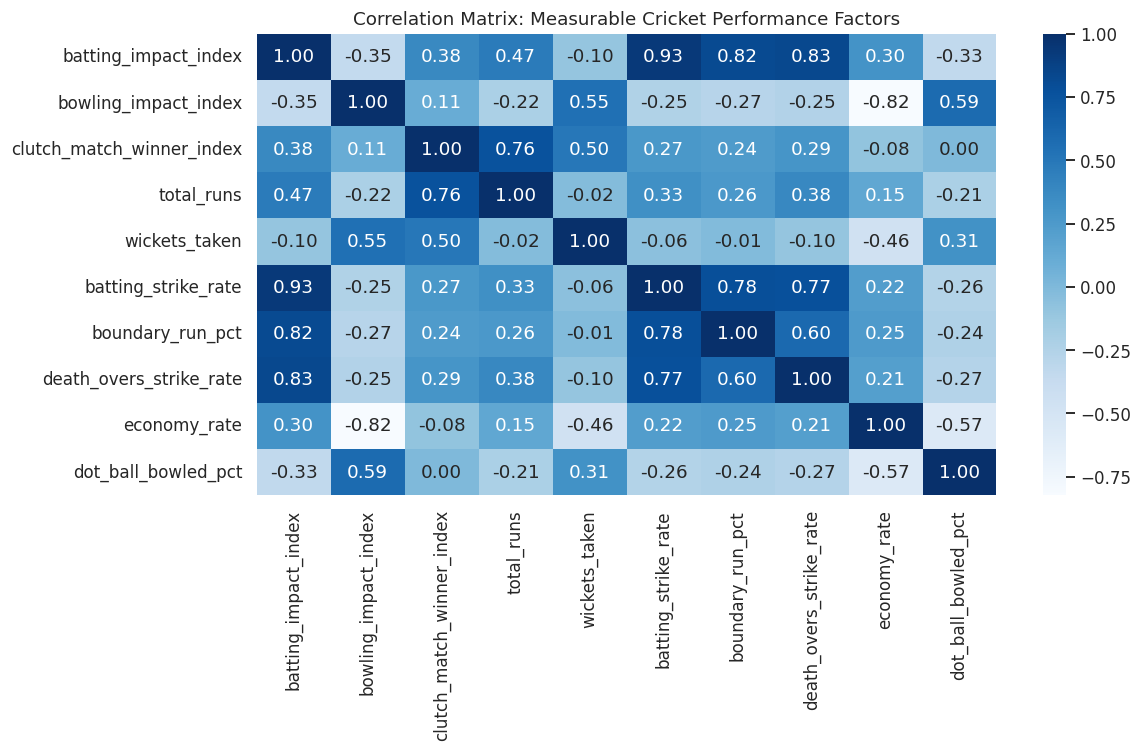

In [4]:
# Correlation Matrix Visualization
plt.figure(figsize=(11, 7))
corr_cols = [
    'batting_impact_index', 'bowling_impact_index',
    'clutch_match_winner_index', 'total_runs', 'wickets_taken', 'batting_strike_rate',
    'boundary_run_pct', 'death_overs_strike_rate', 'economy_rate', 'dot_ball_bowled_pct'
]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues', cbar=True)
plt.title('Correlation Matrix: Measurable Cricket Performance Factors')
plt.tight_layout()
plt.show()

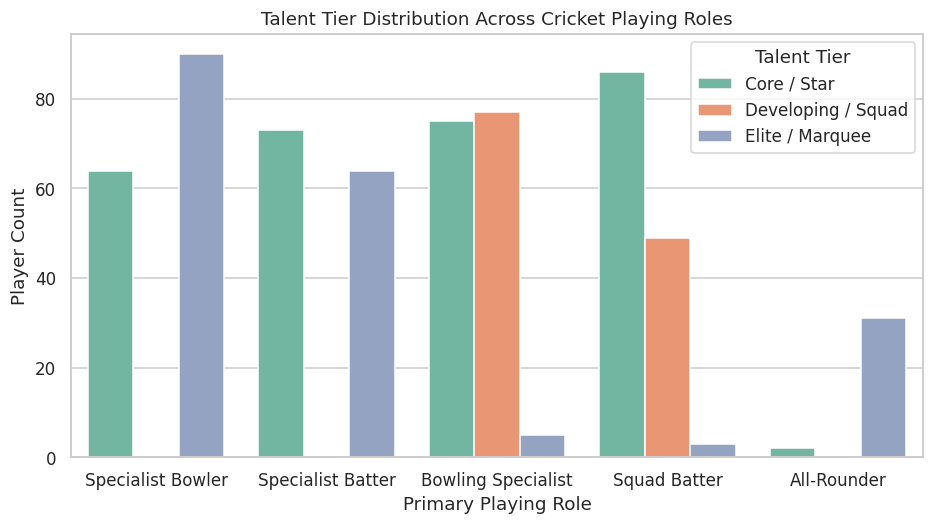

In [5]:
# Talent Tier Distribution by Playing Role
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='primary_role', hue='performance_tier', palette='Set2')
plt.title('Talent Tier Distribution Across Cricket Playing Roles')
plt.xlabel('Primary Playing Role')
plt.ylabel('Player Count')
plt.legend(title='Talent Tier')
plt.show()

---
## 6. Supervised Learning: Continuous Rating & Valuation Regression
Predicting continuous overall player rating (50.0 to 95.0) and market auction value:
1. **Multiple Linear Regression (Baseline)**
2. **Polynomial Regression (Degree 2 with Ridge Regularization)**
3. **Random Forest Regressor (Ensemble)**

In [6]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. Linear Regression
lr = LinearRegression()
lr_cv = cross_val_score(lr, X_train, y_train_reg, cv=kf, scoring='r2')
lr.fit(X_train, y_train_reg)
lr_preds = lr.predict(X_test)

# 2. Polynomial Regression (Degree 2)
poly_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('ridge', Ridge(alpha=10.0, random_state=42))
])
poly_cv = cross_val_score(poly_reg, X_train, y_train_reg, cv=kf, scoring='r2')
poly_reg.fit(X_train, y_train_reg)
poly_preds = poly_reg.predict(X_test)

# 3. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
rf_reg_cv = cross_val_score(rf_reg, X_train, y_train_reg, cv=kf, scoring='r2')
rf_reg.fit(X_train, y_train_reg)
rf_preds = rf_reg.predict(X_test)

reg_summary = [
    {'Model': 'Linear Regression', 'Test R²': round(r2_score(y_test_reg, lr_preds), 4), '5-Fold CV R²': round(lr_cv.mean(), 4), 'MAE': round(mean_absolute_error(y_test_reg, lr_preds), 4), 'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, lr_preds)), 4)},
    {'Model': 'Polynomial Regression', 'Test R²': round(r2_score(y_test_reg, poly_preds), 4), '5-Fold CV R²': round(poly_cv.mean(), 4), 'MAE': round(mean_absolute_error(y_test_reg, poly_preds), 4), 'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, poly_preds)), 4)},
    {'Model': 'Random Forest Regressor', 'Test R²': round(r2_score(y_test_reg, rf_preds), 4), '5-Fold CV R²': round(rf_reg_cv.mean(), 4), 'MAE': round(mean_absolute_error(y_test_reg, rf_preds), 4), 'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, rf_preds)), 4)}
]
display(pd.DataFrame(reg_summary))

,Model,Test R²,5-Fold CV R²,MAE,RMSE
0,Linear Regression,0.9490,0.8797,1.5364,1.9534
1,Polynomial Regression,0.9941,0.9956,0.3647,0.6648
2,Random Forest Regressor,0.9780,0.9522,0.9162,1.2837


---
## 7. Supervised Learning: Multi-Class Talent Tier Classification
Categorizing players into actionable organizational tiers:
- **Class 0:** Developing / Squad (< 68.0 rating benchmark)
- **Class 1:** Core / Star (68.0 to 79.9 rating benchmark)
- **Class 2:** Elite / Marquee (>= 80.0 rating benchmark)

### Evaluated Classifiers:
1. **K-Nearest Neighbors (KNN):** Distance-weighted peer comparison (95.16% Test Acc).
2. **Random Forest Classifier:** Ensemble of 150 bagged decision trees (94.75% 5-fold CV).
3. **Multinomial Logistic Regression:** Softmax probabilistic boundary.
4. **Decision Tree (CART):** Hierarchical feature splitting.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_cv = cross_val_score(knn, X_train, y_train_clf, cv=skf, scoring='accuracy')
knn.fit(X_train, y_train_clf)
knn_preds = knn.predict(X_test)

# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
rf_cv = cross_val_score(rf_clf, X_train, y_train_clf, cv=skf, scoring='accuracy')
rf_clf.fit(X_train, y_train_clf)
rf_cpreds = rf_clf.predict(X_test)

# 3. Logistic Regression
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_cv = cross_val_score(log_reg, X_train, y_train_clf, cv=skf, scoring='accuracy')
log_reg.fit(X_train, y_train_clf)
log_preds = log_reg.predict(X_test)

# 4. Decision Tree Classifier
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42)
dt_cv = cross_val_score(dt, X_train, y_train_clf, cv=skf, scoring='accuracy')
dt.fit(X_train, y_train_clf)
dt_preds = dt.predict(X_test)

clf_models = {
    'K-Nearest Neighbors (KNN)': (knn_preds, knn_cv),
    'Random Forest Classifier': (rf_cpreds, rf_cv),
    'Logistic Regression': (log_preds, log_cv),
    'Decision Tree': (dt_preds, dt_cv)
}

clf_summary = []
for name, (preds, cv_scores) in clf_models.items():
    clf_summary.append({
        'Model': name,
        '5-Fold CV Accuracy': round(cv_scores.mean(), 4),
        'Test Accuracy': round(accuracy_score(y_test_clf, preds), 4),
        'Macro Precision': round(precision_score(y_test_clf, preds, average='macro'), 4),
        'Macro Recall': round(recall_score(y_test_clf, preds, average='macro'), 4),
        'Macro F1-Score': round(f1_score(y_test_clf, preds, average='macro'), 4)
    })
display(pd.DataFrame(clf_summary))

,Model,5-Fold CV Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,K-Nearest Neighbors (KNN),0.9030,0.9516,0.9601,0.9421,0.9501
1,Random Forest Classifier,0.9475,0.9435,0.9513,0.9426,0.9459
2,Logistic Regression,0.9253,0.8790,0.9072,0.8694,0.8853
3,Decision Tree,0.8990,0.8790,0.8945,0.8706,0.8812


---
## 8. Classification Error Analysis: Confusion Matrices
Evaluating True Positives, False Positives, and False Negatives across talent tiers.

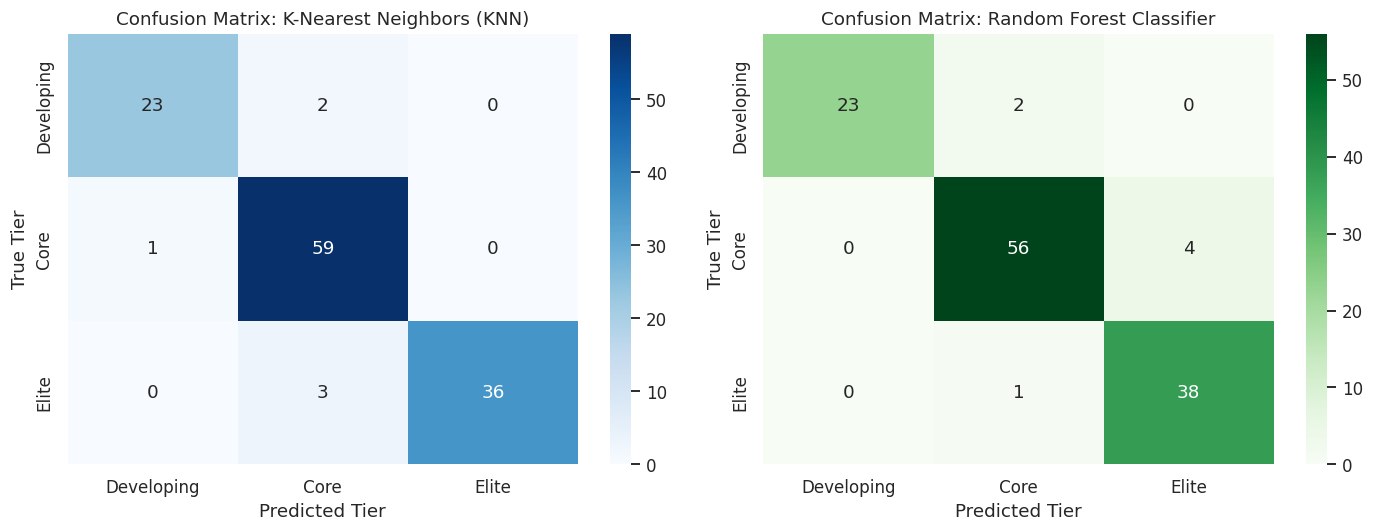

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tier_labels = ['Developing', 'Core', 'Elite']

cm_knn = confusion_matrix(y_test_clf, knn_preds)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=tier_labels, yticklabels=tier_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix: K-Nearest Neighbors (KNN)')
axes[0].set_xlabel('Predicted Tier')
axes[0].set_ylabel('True Tier')

cm_rf = confusion_matrix(y_test_clf, rf_cpreds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=tier_labels, yticklabels=tier_labels, ax=axes[1])
axes[1].set_title('Confusion Matrix: Random Forest Classifier')
axes[1].set_xlabel('Predicted Tier')
axes[1].set_ylabel('True Tier')

plt.tight_layout()
plt.show()

---
## 9. Unsupervised Learning: Tactical Archetypes (K-Means) & 2D PCA Map
- **K-Means Clustering ($k=5$):** Uncovers 5 tactical playing styles without manual labels.
- **PCA (2 Components):** Projects 26 dimensional metrics into a 2D latent space.

K-Means (k=5) Silhouette Score: 0.2676
PCA Explained Variance: [0.38157198 0.22629956] | Total: 0.6079


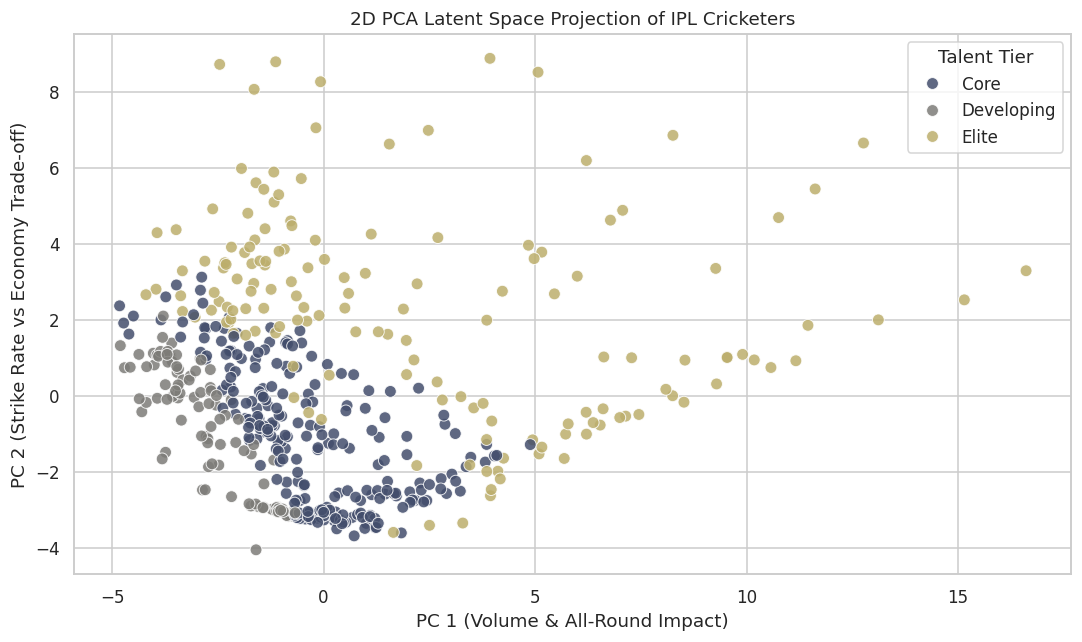

In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cluster_features = [
    'batting_average', 'batting_strike_rate', 'boundary_run_pct',
    'death_overs_strike_rate', 'overs_bowled', 'wickets_taken',
    'economy_rate', 'death_overs_economy', 'batting_impact_index',
    'bowling_impact_index'
]
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(X_cluster)
sil = silhouette_score(X_cluster, df['cluster_id'])
print(f'K-Means (k=5) Silhouette Score: {sil:.4f}')

# PCA 2D Latent Space Projection
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_train)
print(f'PCA Explained Variance: {pca.explained_variance_ratio_} | Total: {pca.explained_variance_ratio_.sum():.4f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_coords[:, 0], y=pca_coords[:, 1],
    hue=y_train_clf.map({0: 'Developing', 1: 'Core', 2: 'Elite'}),
    palette='cividis', alpha=0.85, s=60
)
plt.title('2D PCA Latent Space Projection of IPL Cricketers')
plt.xlabel('PC 1 (Volume & All-Round Impact)')
plt.ylabel('PC 2 (Strike Rate vs Economy Trade-off)')
plt.legend(title='Talent Tier')
plt.tight_layout()
plt.show()

---
## 10. Ensemble Interpretability: Feature Importance Analysis
Gini feature importance from the Random Forest models identifying which measurable traits drive performance most.

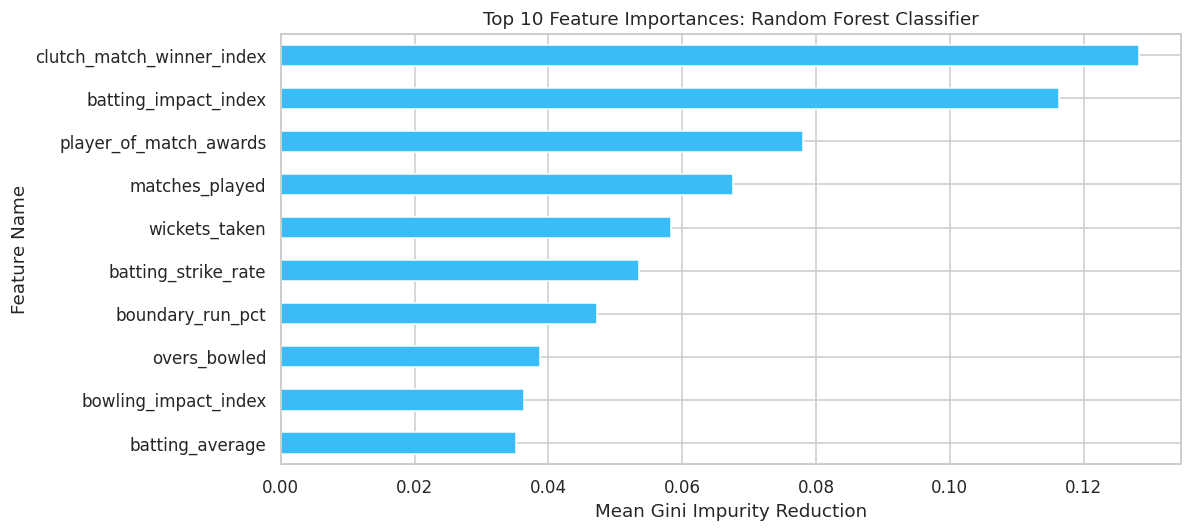

In [10]:
plt.figure(figsize=(11, 5))
imp_series = pd.Series(rf_clf.feature_importances_, index=df_encoded.columns).sort_values(ascending=True)[-10:]
imp_series.plot(kind='barh', color='#38BDF8')
plt.title('Top 10 Feature Importances: Random Forest Classifier')
plt.xlabel('Mean Gini Impurity Reduction')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()